# Pulsed ODMR result plots

Results from `pulsed_odmr.py` (pulsed ODMR frequency sweep, `rabi.py`'s
gated laser/MW pulse sequence with a fixed `tau_mw_us`, only `freq_hz`
swept). Split out from `rabi_result.ipynb` (which covers `rabi.py`'s own
`tau_mw` Rabi sweeps) since the two are separate measurement types.

## Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

DATA_DIR = "D:/rabi"

## pulsed1 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=5.0` us, `n_reps=250`, `coil_current_a=2.5`, fixed shot period per
point (frequency sweep, not `tau_mw`). 5/144 points (`3.5%`) show
`reference_unlock=True` -- EXCLUDED from the fit (see the `pulsed3` entry
below for why: an unlock-flagged point can be a severe corrupted-reading
outlier, not just a noisy one). Fits R vs. frequency to a single
Lorentzian dip/peak to extract the ODMR linewidth (FWHM).

pulsed1: 144 points, 2.896675-2.910975 GHz
5/144 points flagged reference_unlock (excluded from fit)
tau_mw_us=5.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
anchor_free_reps=1000
extra_settle_s=1.0
coil_current_a=2.5


pulsed1 Lorentzian fit: f0 = 2.900940 GHz, FWHM (linewidth) = 23.6900 +/- 10.9576 MHz
[UNRELIABLE] relative uncertainty 46%, fitted FWHM is 166% of the scanned span (14.3 MHz) -- the window likely doesn't fully contain both wings of the resonance; widen start_hz/stop_hz before trusting this number


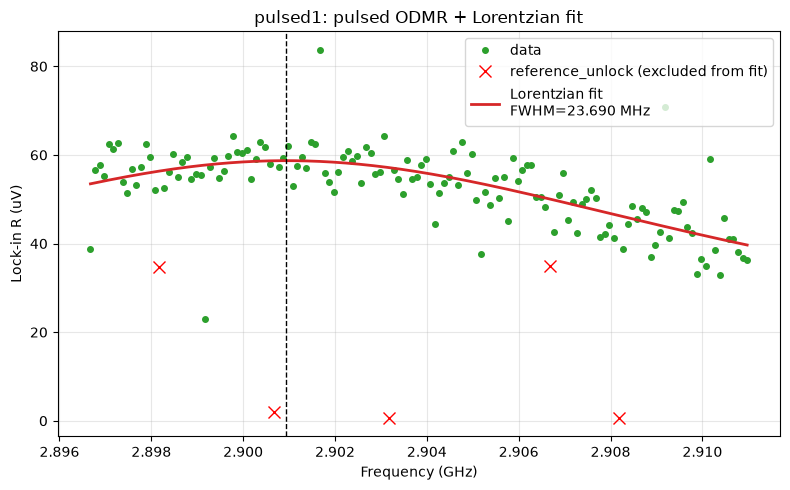

In [2]:
name_p1 = "pulsed1"
run_path_p1 = f"{DATA_DIR}/{name_p1}"
freqs_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_freqs_hz.npy")
x_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_x.npy")
y_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_y.npy")
r_p1 = np.sqrt(x_p1**2 + y_p1**2)
unlock_p1 = np.load(f"{run_path_p1}/{name_p1}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p1}/{name_p1}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p1 = fh.read()
print(f"{name_p1}: {len(freqs_p1)} points, {freqs_p1.min()/1e9:.6f}-{freqs_p1.max()/1e9:.6f} GHz")
print(f"{unlock_p1.sum()}/{len(unlock_p1)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p1)


def lorentzian(f, f0, fwhm, amp, offset):
    """amp can be negative (dip) or positive (peak); fwhm only appears
    squared below, so curve_fit can converge to either sign -- always
    take abs(fwhm) when reporting/plotting the fitted linewidth."""
    hwhm = fwhm / 2
    return offset + amp * hwhm**2 / ((f - f0)**2 + hwhm**2)


def report_lorentzian_fit(name, freqs_ghz, r, unlock, span_ghz):
    """Fits r vs freqs_ghz (excluding unlock-flagged points) to a single
    Lorentzian, reports f0/FWHM with abs(fwhm) (sign is a fit degeneracy,
    not physical), and flags the fit as unreliable if FWHM's relative
    uncertainty is large or the fitted FWHM approaches the scanned span
    (both signs that the window doesn't fully contain the lineshape)."""
    good = ~unlock
    median_r = np.median(r[good])
    idx_extreme = np.argmax(np.abs(r[good] - median_r))
    p0 = [freqs_ghz[good][idx_extreme], span_ghz / 4,
          r[good][idx_extreme] - median_r, median_r]

    popt, pcov = curve_fit(lorentzian, freqs_ghz[good], r[good], p0=p0, maxfev=5000)
    f0_fit, fwhm_fit, amp_fit, offset_fit = popt
    fwhm_fit = abs(fwhm_fit)
    perr = np.sqrt(np.diag(pcov))
    fwhm_err = perr[1]

    rel_err = fwhm_err / fwhm_fit if fwhm_fit > 0 else np.inf
    span_fraction = fwhm_fit / span_ghz
    print(f"\n{name} Lorentzian fit: f0 = {f0_fit:.6f} GHz, "
          f"FWHM (linewidth) = {fwhm_fit*1e3:.4f} +/- {fwhm_err*1e3:.4f} MHz")
    if rel_err > 0.5 or span_fraction > 0.5:
        print(f"[UNRELIABLE] relative uncertainty {rel_err*100:.0f}%, "
              f"fitted FWHM is {span_fraction*100:.0f}% of the scanned span "
              f"({span_ghz*1e3:.1f} MHz) -- the window likely doesn't fully "
              f"contain both wings of the resonance; widen start_hz/stop_hz "
              f"before trusting this number")
    return f0_fit, fwhm_fit, fwhm_err, popt


span_ghz_p1 = (freqs_p1.max() - freqs_p1.min()) / 1e9
freqs_ghz_p1 = freqs_p1 / 1e9
f0_fit, fwhm_fit_ghz, fwhm_err_ghz, popt = report_lorentzian_fit(
    name_p1, freqs_ghz_p1, r_p1, unlock_p1, span_ghz_p1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p1[~unlock_p1], r_p1[~unlock_p1] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p1[unlock_p1], r_p1[unlock_p1] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit = np.linspace(freqs_ghz_p1.min(), freqs_ghz_p1.max(), 1000)
ax.plot(freqs_fit, lorentzian(freqs_fit, *popt) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz*1e3:.3f} MHz")
ax.axvline(f0_fit, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p1}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed2 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=5.0` us, `n_reps=250`, `coil_current_a=4.0` (different from
`pulsed1`'s `2.5` A -- a different coil-scan optimum/resonance point).
5/122 points (`4.1%`) show `reference_unlock=True` -- excluded from the
fit, same as `pulsed1`. Reuses the `lorentzian()` fit function defined
above.

pulsed2: 122 points, 2.794700-2.806800 GHz
5/122 points flagged reference_unlock (excluded from fit)
tau_mw_us=5.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
anchor_free_reps=1000
extra_settle_s=1.0
coil_current_a=4.0


pulsed2 Lorentzian fit: f0 = 2.805155 GHz, FWHM (linewidth) = 11.3874 +/- 4.5949 MHz
[UNRELIABLE] relative uncertainty 40%, fitted FWHM is 94% of the scanned span (12.1 MHz) -- the window likely doesn't fully contain both wings of the resonance; widen start_hz/stop_hz before trusting this number


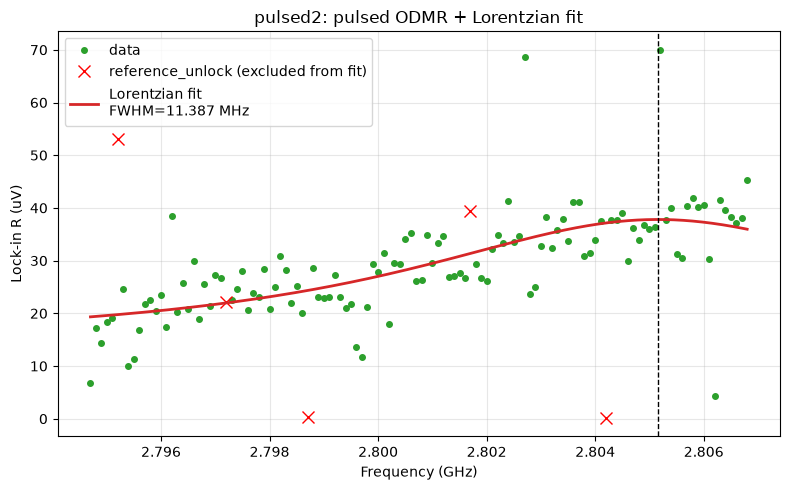

In [3]:
name_p2 = "pulsed2"
run_path_p2 = f"{DATA_DIR}/{name_p2}"
freqs_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_freqs_hz.npy")
x_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_x.npy")
y_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_y.npy")
r_p2 = np.sqrt(x_p2**2 + y_p2**2)
unlock_p2 = np.load(f"{run_path_p2}/{name_p2}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p2}/{name_p2}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p2 = fh.read()
print(f"{name_p2}: {len(freqs_p2)} points, {freqs_p2.min()/1e9:.6f}-{freqs_p2.max()/1e9:.6f} GHz")
print(f"{unlock_p2.sum()}/{len(unlock_p2)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p2)

span_ghz_p2 = (freqs_p2.max() - freqs_p2.min()) / 1e9
freqs_ghz_p2 = freqs_p2 / 1e9
f0_fit2, fwhm_fit_ghz2, fwhm_err_ghz2, popt2 = report_lorentzian_fit(
    name_p2, freqs_ghz_p2, r_p2, unlock_p2, span_ghz_p2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p2[~unlock_p2], r_p2[~unlock_p2] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p2[unlock_p2], r_p2[unlock_p2] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit2 = np.linspace(freqs_ghz_p2.min(), freqs_ghz_p2.max(), 1000)
ax.plot(freqs_fit2, lorentzian(freqs_fit2, *popt2) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz2*1e3:.3f} MHz")
ax.axvline(f0_fit2, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p2}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed3 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=5.0` us, `n_reps=250`, `coil_current_a=3.0`. 4/112 points (`3.6%`)
show `reference_unlock=True`.

**Found while fitting this one**: the fit's initial-guess logic (pick the
point farthest from the median as the resonance extremum) originally
picked one of the `reference_unlock`-flagged points -- a single corrupted
reading near zero (`R~0.27 uV`) sandwiched between neighbors reading
`~65-70 uV` on both sides -- as the "dip," which then made `curve_fit`
fail to converge entirely (`Optimal parameters not found`). Fixed by
excluding `reference_unlock`-flagged points from the fit across all three
`pulsed*` cells above (not just flagging them cosmetically as before) --
they're shown on the plot as red X's but never used for the initial guess
or the fit itself.

pulsed3: 112 points, 2.833900-2.845000 GHz
4/112 points flagged reference_unlock (excluded from fit)
tau_mw_us=5.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
anchor_free_reps=1000
extra_settle_s=1.0
coil_current_a=3.0


pulsed3 Lorentzian fit: f0 = 2.838557 GHz, FWHM (linewidth) = 694.4767 +/- 1178918.8937 MHz
[UNRELIABLE] relative uncertainty 169756%, fitted FWHM is 6257% of the scanned span (11.1 MHz) -- the window likely doesn't fully contain both wings of the resonance; widen start_hz/stop_hz before trusting this number


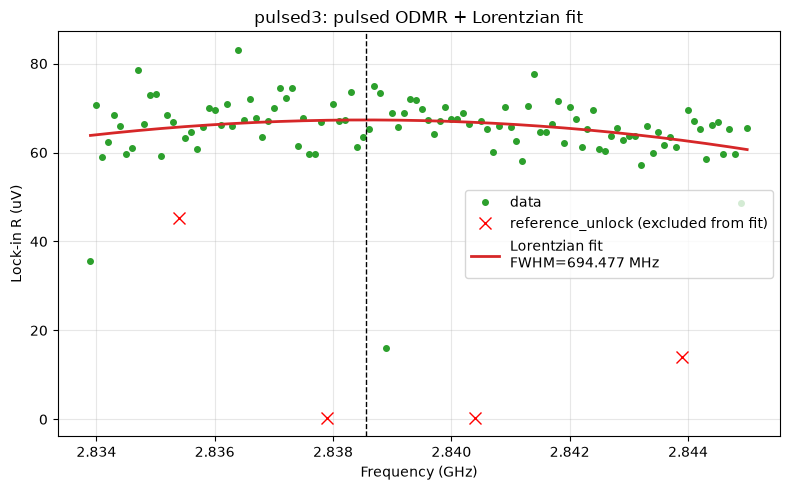

In [4]:
name_p3 = "pulsed3"
run_path_p3 = f"{DATA_DIR}/{name_p3}"
freqs_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_freqs_hz.npy")
x_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_x.npy")
y_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_y.npy")
r_p3 = np.sqrt(x_p3**2 + y_p3**2)
unlock_p3 = np.load(f"{run_path_p3}/{name_p3}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p3}/{name_p3}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p3 = fh.read()
print(f"{name_p3}: {len(freqs_p3)} points, {freqs_p3.min()/1e9:.6f}-{freqs_p3.max()/1e9:.6f} GHz")
print(f"{unlock_p3.sum()}/{len(unlock_p3)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p3)

span_ghz_p3 = (freqs_p3.max() - freqs_p3.min()) / 1e9
freqs_ghz_p3 = freqs_p3 / 1e9
f0_fit3, fwhm_fit_ghz3, fwhm_err_ghz3, popt3 = report_lorentzian_fit(
    name_p3, freqs_ghz_p3, r_p3, unlock_p3, span_ghz_p3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p3[~unlock_p3], r_p3[~unlock_p3] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p3[unlock_p3], r_p3[unlock_p3] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit3 = np.linspace(freqs_ghz_p3.min(), freqs_ghz_p3.max(), 1000)
ax.plot(freqs_fit3, lorentzian(freqs_fit3, *popt3) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz3*1e3:.3f} MHz")
ax.axvline(f0_fit3, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p3}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed4 (pulsed_odmr.py frequency sweep) + Lorentzian fit

`tau_mw=2.0` us, `n_reps=250`, `coil_current_a=2.5`, `anchor_free_reps=
80000` (up from `1000` in pulsed1-3) with `extra_settle_s=1.0`. **0/201
points show `reference_unlock=True`** -- fully clean, confirming the
`trigger_period_s`/`trigger_retrigger_free_reps` decoupling fix (added
this session after `measurement21-25`/`pulsed_odmr.py` investigation)
actually works on real hardware: a large `anchor_free_reps` no longer
drags the SDG1062X retrigger rate down with it. Widest scan yet (201
points, 20 MHz span, same as `pulsed1`'s span but far denser).

pulsed4: 201 points, 2.830000-2.850000 GHz
0/201 points flagged reference_unlock (excluded from fit)
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5


pulsed4 Lorentzian fit: f0 = 2.830529 GHz, FWHM (linewidth) = 7.0874 +/- 1.3134 MHz


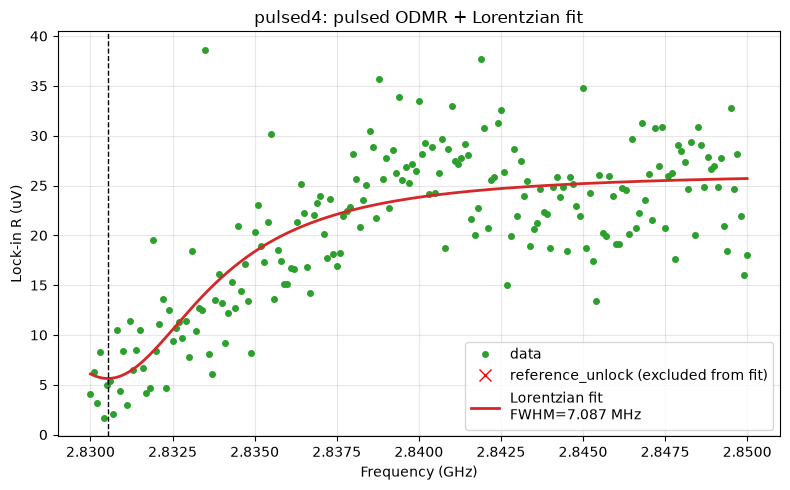

In [5]:
name_p4 = "pulsed4"
run_path_p4 = f"{DATA_DIR}/{name_p4}"
freqs_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_freqs_hz.npy")
x_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_x.npy")
y_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_y.npy")
r_p4 = np.sqrt(x_p4**2 + y_p4**2)
unlock_p4 = np.load(f"{run_path_p4}/{name_p4}_pulsed_odmr_reference_unlock.npy")

with open(f"{run_path_p4}/{name_p4}_pulsed_odmr_metadata.txt") as fh:
    metadata_text_p4 = fh.read()
print(f"{name_p4}: {len(freqs_p4)} points, {freqs_p4.min()/1e9:.6f}-{freqs_p4.max()/1e9:.6f} GHz")
print(f"{unlock_p4.sum()}/{len(unlock_p4)} points flagged reference_unlock (excluded from fit)")
print(metadata_text_p4)

span_ghz_p4 = (freqs_p4.max() - freqs_p4.min()) / 1e9
freqs_ghz_p4 = freqs_p4 / 1e9
f0_fit4, fwhm_fit_ghz4, fwhm_err_ghz4, popt4 = report_lorentzian_fit(
    name_p4, freqs_ghz_p4, r_p4, unlock_p4, span_ghz_p4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_p4[~unlock_p4], r_p4[~unlock_p4] * 1e6, "o", ms=4, color="tab:green", label="data")
ax.plot(freqs_ghz_p4[unlock_p4], r_p4[unlock_p4] * 1e6, "x", ms=8, color="red",
        label="reference_unlock (excluded from fit)")
freqs_fit4 = np.linspace(freqs_ghz_p4.min(), freqs_ghz_p4.max(), 1000)
ax.plot(freqs_fit4, lorentzian(freqs_fit4, *popt4) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz4*1e3:.3f} MHz")
ax.axvline(f0_fit4, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_p4}: pulsed ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged: pulsed4 + pulsed5, double-Lorentzian fit

Same frequency grid confirmed matching exactly (201 points, 2.83-2.85
GHz), same params (`tau_mw=2.0` us, `coil_current_a=2.5` A,
`anchor_free_reps=80000`), both fully clean (0 `reference_unlock` points
in either). Averaged elementwise (X/Y averaged first, then R from the
averaged X/Y, excluding any unlock-flagged points -- none here, but kept
for consistency with the other `pulsed*` cells). Fits a sum of two
independent Lorentzian peaks (same `double_lorentzian()` used on
`measurement_scan_dense` in `cw_odmr_result.ipynb`), with an AIC
comparison against a single-Lorentzian fit to check whether the second
peak actually earns its added complexity on this data.

pulsed4: 201 points, 2.830000-2.850000 GHz, 0/201 unlock
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5

pulsed5: 201 points, 2.830000-2.850000 GHz, 0/201 unlock
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5


Peak 1: f0 = 2.839634 GHz, FWHM = 11.8532 +/- 1.6576 MHz, amp = 26.162 uV
Peak 2: f0 = 2.848482 GHz, FWHM = 9.0726 +/- 2.2277 MHz, amp = 18.963 uV
Peak separation: 8.848 MHz
[NOTE] peak separation is smaller than the average of the two fitted widths -- the two peaks strongly overlap

Single Lorentzian: RSS = 2508.888 (uV^2), AIC = -5038.45
Double Lorentzian: RSS = 1690.477 (uV^2), AIC = -5111.81
Do

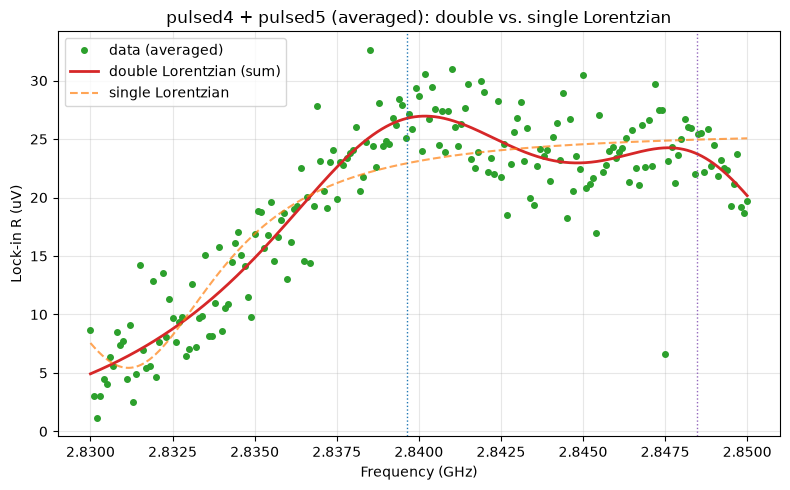

In [6]:
pool_names_p45 = ["pulsed4", "pulsed5"]

pool_data_p45 = []
for name in pool_names_p45:
    run_path = f"{DATA_DIR}/{name}"
    freqs = np.load(f"{run_path}/{name}_pulsed_odmr_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_pulsed_odmr_x.npy")
    y = np.load(f"{run_path}/{name}_pulsed_odmr_y.npy")
    unlock = np.load(f"{run_path}/{name}_pulsed_odmr_reference_unlock.npy")
    with open(f"{run_path}/{name}_pulsed_odmr_metadata.txt") as fh:
        print(f"{name}: {len(freqs)} points, {freqs.min()/1e9:.6f}-{freqs.max()/1e9:.6f} GHz, "
              f"{unlock.sum()}/{len(unlock)} unlock")
        print(fh.read())
    pool_data_p45.append(dict(freqs=freqs, x=x, y=y, unlock=unlock))

freqs_p45 = pool_data_p45[0]["freqs"]
assert all(np.allclose(d["freqs"], freqs_p45) for d in pool_data_p45), \
    "frequency grids must match exactly to average elementwise"

# Points flagged reference_unlock in EITHER run are excluded from both
# before averaging (none here, but kept consistent with the other
# pulsed* cells' convention of never trusting an unlock-flagged point).
unlock_p45 = np.any([d["unlock"] for d in pool_data_p45], axis=0)
good_p45 = ~unlock_p45

x_avg_p45 = np.mean([d["x"] for d in pool_data_p45], axis=0)
y_avg_p45 = np.mean([d["y"] for d in pool_data_p45], axis=0)
r_avg_p45 = np.sqrt(x_avg_p45**2 + y_avg_p45**2)

freqs_ghz_p45 = freqs_p45 / 1e9
span_ghz_p45 = freqs_ghz_p45.max() - freqs_ghz_p45.min()


def double_lorentzian(f, f1, fwhm1, amp1, f2, fwhm2, amp2, offset):
    """Sum of two independent Lorentzian peaks + one shared baseline
    offset. Each fwhm only appears squared -- take abs() when reporting."""
    term1 = amp1 * (fwhm1 / 2) ** 2 / ((f - f1) ** 2 + (fwhm1 / 2) ** 2)
    term2 = amp2 * (fwhm2 / 2) ** 2 / ((f - f2) ** 2 + (fwhm2 / 2) ** 2)
    return offset + term1 + term2


# Initial guess: split the (good) range in half, use each half's own max
# as a candidate peak center -- same robust strategy as the cw_odmr_
# result.ipynb double-Lorentzian fit.
freqs_good_p45 = freqs_ghz_p45[good_p45]
r_good_p45 = r_avg_p45[good_p45]
mid_p45 = len(freqs_good_p45) // 2
left_f, right_f = freqs_good_p45[:mid_p45], freqs_good_p45[mid_p45:]
left_r, right_r = r_good_p45[:mid_p45], r_good_p45[mid_p45:]
median_r_p45 = np.median(r_good_p45)

idx_left = np.argmax(left_r)
idx_right = np.argmax(right_r)
p0_dbl_p45 = [
    left_f[idx_left], span_ghz_p45 / 8, left_r[idx_left] - median_r_p45,
    right_f[idx_right], span_ghz_p45 / 8, right_r[idx_right] - median_r_p45,
    median_r_p45,
]

popt_dbl_p45, pcov_dbl_p45 = curve_fit(
    double_lorentzian, freqs_good_p45, r_good_p45, p0=p0_dbl_p45, maxfev=10000)
f1_p45, fwhm1_p45, amp1_p45, f2_p45, fwhm2_p45, amp2_p45, offset_p45 = popt_dbl_p45
fwhm1_p45, fwhm2_p45 = abs(fwhm1_p45), abs(fwhm2_p45)
perr_dbl_p45 = np.sqrt(np.diag(pcov_dbl_p45))

print(f"\nPeak 1: f0 = {f1_p45:.6f} GHz, FWHM = {fwhm1_p45*1e3:.4f} +/- "
      f"{perr_dbl_p45[1]*1e3:.4f} MHz, amp = {amp1_p45*1e6:.3f} uV")
print(f"Peak 2: f0 = {f2_p45:.6f} GHz, FWHM = {fwhm2_p45*1e3:.4f} +/- "
      f"{perr_dbl_p45[4]*1e3:.4f} MHz, amp = {amp2_p45*1e6:.3f} uV")
separation_mhz_p45 = abs(f2_p45 - f1_p45) * 1e3
print(f"Peak separation: {separation_mhz_p45:.3f} MHz")
if separation_mhz_p45 < (fwhm1_p45 + fwhm2_p45) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

# AIC comparison against a single Lorentzian on the same (good) data.
p0_single_p45 = [freqs_good_p45[np.argmax(np.abs(r_good_p45 - median_r_p45))],
                 span_ghz_p45 / 4,
                 r_good_p45[np.argmax(np.abs(r_good_p45 - median_r_p45))] - median_r_p45,
                 median_r_p45]
popt_single_p45, _ = curve_fit(lorentzian, freqs_good_p45, r_good_p45,
                                p0=p0_single_p45, maxfev=5000)

n_points_p45 = len(r_good_p45)
rss_single_p45 = np.sum((r_good_p45 - lorentzian(freqs_good_p45, *popt_single_p45)) ** 2)
rss_double_p45 = np.sum((r_good_p45 - double_lorentzian(freqs_good_p45, *popt_dbl_p45)) ** 2)
aic_single_p45 = n_points_p45 * np.log(rss_single_p45 / n_points_p45) + 2 * 4
aic_double_p45 = n_points_p45 * np.log(rss_double_p45 / n_points_p45) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_p45*1e12:.3f} (uV^2), AIC = {aic_single_p45:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_p45*1e12:.3f} (uV^2), AIC = {aic_double_p45:.2f}")
if aic_double_p45 < aic_single_p45:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_p45 - aic_double_p45:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_p45 - aic_single_p45:.2f}) "
          f"-- the second peak is NOT justified by this data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_good_p45, r_good_p45 * 1e6, "o", ms=4, color="tab:green", label="data (averaged)")
freqs_fit_p45 = np.linspace(freqs_ghz_p45.min(), freqs_ghz_p45.max(), 2000)
ax.plot(freqs_fit_p45, double_lorentzian(freqs_fit_p45, *popt_dbl_p45) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.plot(freqs_fit_p45, lorentzian(freqs_fit_p45, *popt_single_p45) * 1e6,
        "--", lw=1.5, color="tab:orange", alpha=0.7, label="single Lorentzian")
ax.axvline(f1_p45, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_p45, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title("pulsed4 + pulsed5 (averaged): double vs. single Lorentzian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## pulsed_repeat (in progress -- only completed repeats so far)

First real-hardware use of `pulsed_odmr.py`'s new `run-repeat` command.
Still running -- 4 repeats completed so far. Auto-discovers completed
repeats and averages X/Y across them (R from the averaged X/Y), same
pattern as `rabi_result.ipynb`'s in-progress `measurement21`/`measurement
22` cells -- re-run this cell later to pick up more repeats as they
finish.

found 5 completed repeats: [0, 1, 2, 3, 4]
averaging 5/5 repeats
tau_mw_us=2.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
drive_power_dbm=0.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=5e-05
phase_deg=0.0
anchor_free_reps=80000
extra_settle_s=1.0
coil_current_a=2.5



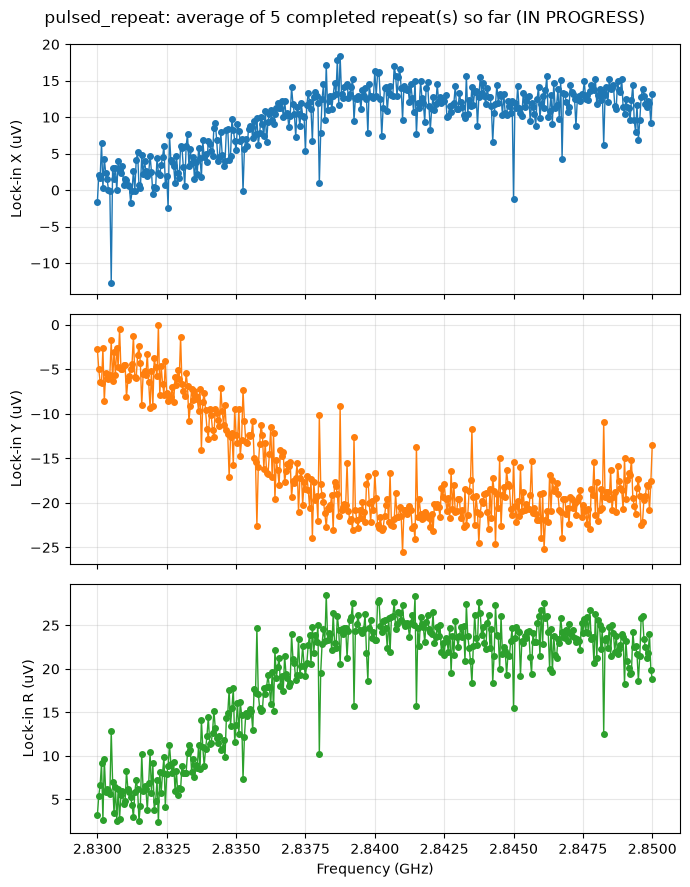

In [7]:
import glob
import re

name_pr = "pulsed_repeat"
run_path_pr = f"{DATA_DIR}/{name_pr}"

repeat_indices_pr = sorted(
    int(re.search(r"_repeat(\d+)_pulsed_odmr_x\.npy$", p).group(1))
    for p in glob.glob(f"{run_path_pr}/{name_pr}_repeat*_pulsed_odmr_x.npy")
)
print(f"found {len(repeat_indices_pr)} completed repeats: {repeat_indices_pr}")

freqs_ref_pr = None
xs_pr, ys_pr = [], []
for i in repeat_indices_pr:
    prefix = f"{run_path_pr}/{name_pr}_repeat{i}"
    freqs_i = np.load(f"{prefix}_pulsed_odmr_freqs_hz.npy")
    if freqs_ref_pr is None:
        freqs_ref_pr = freqs_i
    elif len(freqs_i) != len(freqs_ref_pr) or not np.allclose(freqs_i, freqs_ref_pr):
        print(f"  repeat{i}: freqs_hz grid mismatch ({len(freqs_i)} vs "
              f"{len(freqs_ref_pr)} points) -- excluded")
        continue
    xs_pr.append(np.load(f"{prefix}_pulsed_odmr_x.npy"))
    ys_pr.append(np.load(f"{prefix}_pulsed_odmr_y.npy"))

print(f"averaging {len(xs_pr)}/{len(repeat_indices_pr)} repeats")

with open(f"{run_path_pr}/{name_pr}_repeat0_pulsed_odmr_metadata.txt") as fh:
    print(fh.read())

x_avg_pr = np.mean(xs_pr, axis=0)
y_avg_pr = np.mean(ys_pr, axis=0)
r_avg_pr = np.sqrt(x_avg_pr**2 + y_avg_pr**2)

freqs_ghz_pr = freqs_ref_pr / 1e9

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(freqs_ghz_pr, x_avg_pr * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(freqs_ghz_pr, y_avg_pr * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(freqs_ghz_pr, r_avg_pr * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("Frequency (GHz)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name_pr}: average of {len(xs_pr)} completed repeat(s) so far (IN PROGRESS)")
plt.tight_layout()
plt.show()

## pulsed_repeat: double-Lorentzian fit (in progress)

Same double vs. single Lorentzian comparison as `pulsed4`+`pulsed5`
above, applied to `pulsed_repeat`'s current average (whatever repeats
have completed so far) -- reuses the `lorentzian()`/`double_lorentzian()`
functions already defined above. Re-run after re-running the average
cell above to reflect any newly-completed repeats.

Peak 1: f0 = 2.839082 GHz, FWHM = 10.8811 +/- 1.3310 MHz, amp = 19.971 uV
Peak 2: f0 = 2.848482 GHz, FWHM = 14.8101 +/- 3.5766 MHz, amp = 22.022 uV
Peak separation: 9.399 MHz
[NOTE] peak separation is smaller than the average of the two fitted widths -- the two peaks strongly overlap

Single Lorentzian: RSS = 2724.064 (uV^2), AIC = -10303.76
Double Lorentzian: RSS = 2089.136 (uV^2), AIC = -10404.17
Double Lorentzian preferred (AIC lower by 100.42)


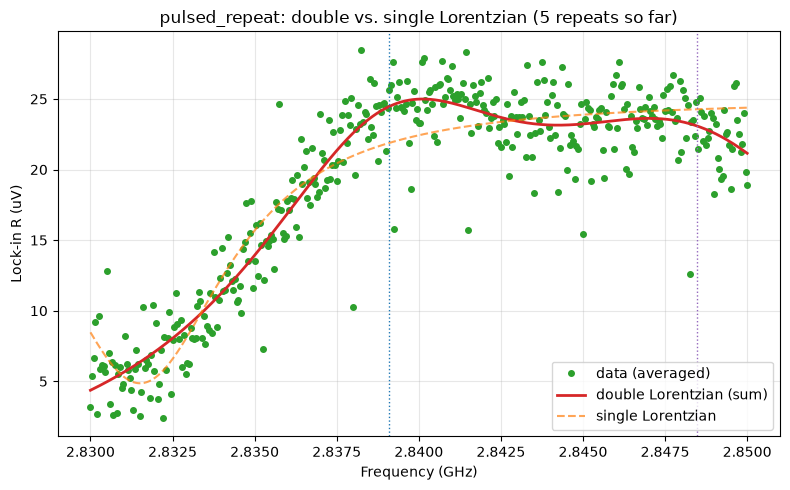

In [8]:
span_ghz_pr = freqs_ghz_pr.max() - freqs_ghz_pr.min()
median_r_pr = np.median(r_avg_pr)

mid_pr = len(freqs_ghz_pr) // 2
left_f_pr, right_f_pr = freqs_ghz_pr[:mid_pr], freqs_ghz_pr[mid_pr:]
left_r_pr, right_r_pr = r_avg_pr[:mid_pr], r_avg_pr[mid_pr:]

idx_left_pr = np.argmax(left_r_pr)
idx_right_pr = np.argmax(right_r_pr)
p0_dbl_pr = [
    left_f_pr[idx_left_pr], span_ghz_pr / 8, left_r_pr[idx_left_pr] - median_r_pr,
    right_f_pr[idx_right_pr], span_ghz_pr / 8, right_r_pr[idx_right_pr] - median_r_pr,
    median_r_pr,
]

popt_dbl_pr, pcov_dbl_pr = curve_fit(
    double_lorentzian, freqs_ghz_pr, r_avg_pr, p0=p0_dbl_pr, maxfev=10000)
f1_pr, fwhm1_pr, amp1_pr, f2_pr, fwhm2_pr, amp2_pr, offset_pr = popt_dbl_pr
fwhm1_pr, fwhm2_pr = abs(fwhm1_pr), abs(fwhm2_pr)
perr_dbl_pr = np.sqrt(np.diag(pcov_dbl_pr))

print(f"Peak 1: f0 = {f1_pr:.6f} GHz, FWHM = {fwhm1_pr*1e3:.4f} +/- "
      f"{perr_dbl_pr[1]*1e3:.4f} MHz, amp = {amp1_pr*1e6:.3f} uV")
print(f"Peak 2: f0 = {f2_pr:.6f} GHz, FWHM = {fwhm2_pr*1e3:.4f} +/- "
      f"{perr_dbl_pr[4]*1e3:.4f} MHz, amp = {amp2_pr*1e6:.3f} uV")
separation_mhz_pr = abs(f2_pr - f1_pr) * 1e3
print(f"Peak separation: {separation_mhz_pr:.3f} MHz")
if separation_mhz_pr < (fwhm1_pr + fwhm2_pr) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

p0_single_pr = [freqs_ghz_pr[np.argmax(np.abs(r_avg_pr - median_r_pr))],
                span_ghz_pr / 4,
                r_avg_pr[np.argmax(np.abs(r_avg_pr - median_r_pr))] - median_r_pr,
                median_r_pr]
popt_single_pr, _ = curve_fit(lorentzian, freqs_ghz_pr, r_avg_pr,
                               p0=p0_single_pr, maxfev=5000)

n_points_pr = len(r_avg_pr)
rss_single_pr = np.sum((r_avg_pr - lorentzian(freqs_ghz_pr, *popt_single_pr)) ** 2)
rss_double_pr = np.sum((r_avg_pr - double_lorentzian(freqs_ghz_pr, *popt_dbl_pr)) ** 2)
aic_single_pr = n_points_pr * np.log(rss_single_pr / n_points_pr) + 2 * 4
aic_double_pr = n_points_pr * np.log(rss_double_pr / n_points_pr) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_pr*1e12:.3f} (uV^2), AIC = {aic_single_pr:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_pr*1e12:.3f} (uV^2), AIC = {aic_double_pr:.2f}")
if aic_double_pr < aic_single_pr:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_pr - aic_double_pr:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_pr - aic_single_pr:.2f}) "
          f"-- the second peak is NOT justified by this data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_pr, r_avg_pr * 1e6, "o", ms=4, color="tab:green", label="data (averaged)")
freqs_fit_pr = np.linspace(freqs_ghz_pr.min(), freqs_ghz_pr.max(), 2000)
ax.plot(freqs_fit_pr, double_lorentzian(freqs_fit_pr, *popt_dbl_pr) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.plot(freqs_fit_pr, lorentzian(freqs_fit_pr, *popt_single_pr) * 1e6,
        "--", lw=1.5, color="tab:orange", alpha=0.7, label="single Lorentzian")
ax.axvline(f1_pr, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_pr, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_pr}: double vs. single Lorentzian ({len(xs_pr)} repeats so far)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()